In [4]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


In [5]:
url = "https://raw.githubusercontent.com/hugofernandobocanegra2/Fisica_Computacional_1/refs/heads/main/Sesiones/seaborn/millas_por_galon.csv"
df = pd.read_csv(url)


#**Visualización rápida usando seaborn.**

> Agregar bloque entrecomillado



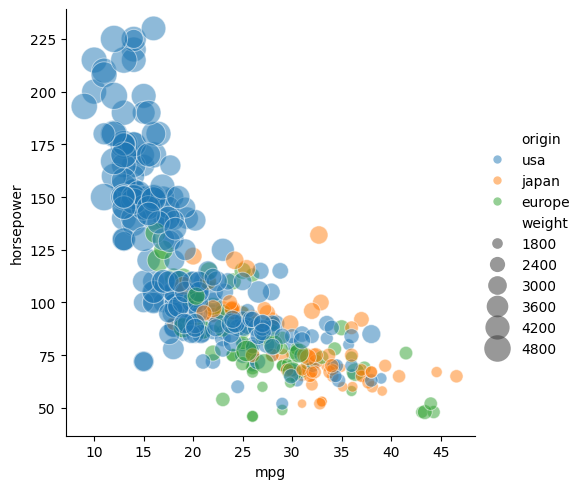

In [5]:
sns.relplot(data=df ,x='mpg',y='horsepower',hue='origin',size="weight",sizes=(40,400),alpha=0.5);

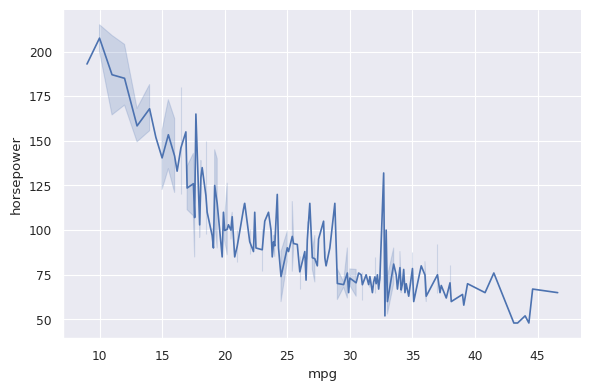

In [28]:
sns.set_theme(context='paper')
#g = sns.relplot(data=df ,kind= "line", x='mpg',y='horsepower',hue='origin',size="weight")
g = sns.relplot(data=df ,kind= "line", x='mpg',y='horsepower',height=4, aspect=1.5)


#Ajuste usando **curve_fit**

Valores ajustados: m=-3.839±0.157, b=194.476±3.873


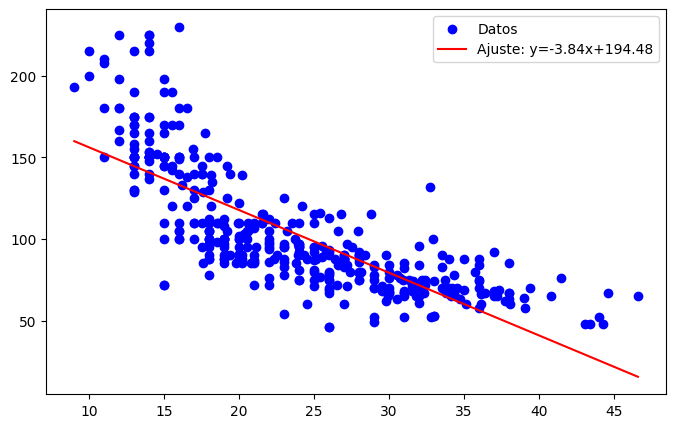

In [6]:

# PASO 1: Datos
# Eliminar filas con valores NaN en 'mpg' o 'horsepower'
# usando el método dropna de pandas

df_limpio = df.dropna(subset=['mpg', 'horsepower'])

x = df_limpio['mpg']
y = df_limpio['horsepower']

# PASO 2: Definir modelo lineal
def modelo_lineal(x, m, b):
    return m * x + b

# PASO 3: Ajustar
# curve_fit devuelve una tupla : popt y pcov

# popt contendrá [m_opt, b_opt], que son la
# pendiente y el intercepto óptimos del modelo lineal.

#  pcov matriz de covarianza estimada de los parámetros ajustados.

#Es una matriz cuadrada donde el número de filas y columnas es igual
# al número de parámetros ajustados (en este cas , 2x2 para m y b

popt, pcov = curve_fit(modelo_lineal, x, y)

# PASO 4: Extraer resultados
m_opt, b_opt = popt

# La raíz cuadrada de los elementos de la diagonal principal de
# pcov (np.sqrt(np.diag(pcov)))  da los errores estándar estimados
# de cada parámetro, que son una medida de la incertidumbre en la estimación
# de esos parámetros.

error_m, error_b = np.sqrt(np.diag(pcov))

print(f"Valores ajustados: m={m_opt:.3f}±{error_m:.3f}, b={b_opt:.3f}±{error_b:.3f}")

# PASO 5: Predecir valores para graficar la línea ajustada
x_linea = np.linspace(min(x), max(x), 100)
y_ajustada = modelo_lineal(x_linea, m_opt, b_opt)

# PASO 6: Visualizar
plt.figure(figsize=(8, 5))
plt.scatter(x, y, color='blue', label='Datos')
plt.plot(x_linea, y_ajustada, 'r-', label=f'Ajuste: y={m_opt:.2f}x+{b_opt:.2f}')
plt.legend()
plt.show()

#**Ajuste usando Seaborn**

<Axes: xlabel='mpg', ylabel='horsepower'>

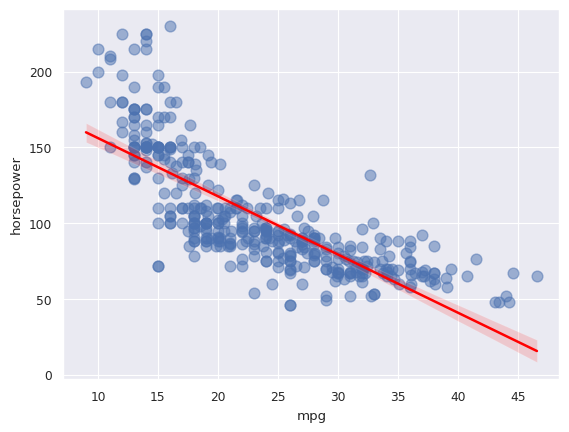

In [29]:
sns.regplot(
    data=df,
    x='mpg',
    y='horsepower',
    scatter_kws={'alpha':0.5, 's':60},  # Estilo de puntos
    line_kws={'color':'red', 'label':'Ajuste lineal'},  # Estilo de línea
    ci=95,  # Intervalo de confianza del 95%
    order=1  # 1=lineal, 2=cuadrático, etc.
)

# **curve_fit + seaborn**

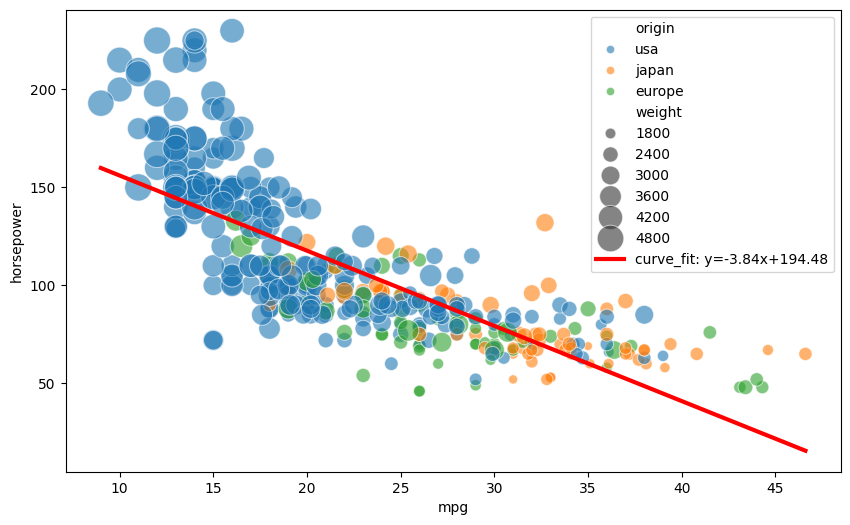

In [7]:

# 1. Hacer el ajuste numérico con curve_fit
def modelo(x, a, b):
    return a * x + b

x_data = df_limpio['mpg'].values
y_data = df_limpio['horsepower'].values
popt, pcov = curve_fit(modelo, x_data, y_data)
a, b = popt

# 2. Graficar con Seaborn para la estética
plt.figure(figsize=(10, 6))

# Scatter con seaborn
sns.scatterplot(
    data=df_limpio,
    x='mpg',
    y='horsepower',
    hue='origin',
    size='weight',
    sizes=(40, 400),
    alpha=0.6
)

# Línea de ajuste manual (usando los parámetros de curve_fit)
x_line = np.linspace(x_data.min(), x_data.max(), 100)
plt.plot(x_line, modelo(x_line, *popt),
         'r-', linewidth=3,
         label=f'curve_fit: y={a:.2f}x+{b:.2f}')

plt.legend()
plt.show()